In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import lomax
from scipy.stats import kstest

############################################################
# LEER ARCHIVO
############################################################

archivo = "Analisis_GATOS_LISTA2.xlsx"

df = pd.read_excel(archivo, sheet_name="Duraciones")

# Duraciones cuando el estado es ACTIVO
ACTIVO = df.loc[df["Estado"] == "ACTIVO", "Duracion_min"].dropna().to_numpy()

# Duraciones cuando el estado es INACTIVO
INACTIVO = df.loc[df["Estado"] == "INACTIVO", "Duracion_min"].dropna().to_numpy()

print(ACTIVO)

print("Número de tiempos activos:", len(ACTIVO))
print("Número de tiempos inactivos:", len(INACTIVO))


############################################################
# AJUSTE LOMAX
############################################################

# loc=0 porque los tiempos comienzan en cero

shape_A, loc_A, scale_A = lomax.fit(ACTIVO, floc=0)

shape_I, loc_I, scale_I = lomax.fit(INACTIVO, floc=0)

print("\nActividad")
print("----------------------")
print("alpha =", shape_A)
print("lambda =", scale_A)

print("\nInactividad")
print("----------------------")
print("alpha =", shape_I)
print("lambda =", scale_I)

print(shape_A/scale_A, 1/scale_A)
print(shape_I/scale_I, 1/scale_I)



############################################################
# TEST KOLMOGOROV-SMIRNOV
############################################################

KS_A = kstest(
    ACTIVO,
    'lomax',
    args=(shape_A, loc_A, scale_A)
)

KS_I = kstest(
    INACTIVO,
    'lomax',
    args=(shape_I, loc_I, scale_I)
)

print("\nKolmogorov-Smirnov")

print("\nActividad")
print(KS_A)

print("\nInactividad")
print(KS_I)

############################################################
# HISTOGRAMA + AJUSTE
############################################################

fig, ax = plt.subplots(1,2, figsize=(12,5))

##############################################

x = np.linspace(0,max(ACTIVO),200)

ax[0].hist(
    ACTIVO,
    bins='auto',
    density=True,
    alpha=0.6,
    edgecolor='k'
)

ax[0].plot(
    x,
    lomax.pdf(x, shape_A, loc_A, scale_A),
    'r',
    lw=3,
    label='Lomax'
)

ax[0].set_title("Actividad")
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("Densidad")
ax[0].legend()

##############################################

x = np.linspace(0,max(INACTIVO),200)

ax[1].hist(
    INACTIVO,
    bins='auto',
    density=True,
    alpha=0.6,
    edgecolor='k'
)

ax[1].plot(
    x,
    lomax.pdf(x, shape_I, loc_I, scale_I),
    'r',
    lw=3,
    label='Lomax'
)

ax[1].set_title("Inactividad")
ax[1].set_xlabel("Tiempo")
ax[1].set_ylabel("Densidad")
ax[1].legend()

plt.tight_layout()
plt.show()

In [97]:
from scipy.stats import lomax
import numpy as np

def bootstrap_lomax(data, B=2000):

    n = len(data)

    alpha_hat, loc_hat, lambda_hat = lomax.fit(data, floc=0)

    alpha_boot = np.zeros(B)
    lambda_boot = np.zeros(B)

    for i in range(B):

        muestra = lomax.rvs(
            alpha_hat,
            loc=0,
            scale=lambda_hat,
            size=n
        )

        a, _, l = lomax.fit(muestra, floc=0)

        alpha_boot[i] = a
        lambda_boot[i] = l

    IC_alpha = np.percentile(alpha_boot,[2.5,97.5])
    IC_lambda = np.percentile(lambda_boot,[2.5,97.5])

    return (
        alpha_hat,
        lambda_hat,
        IC_alpha,
        IC_lambda,
        alpha_boot,
        lambda_boot
    )

In [98]:
alpha_A, lambda_A, IC_alpha_A, IC_lambda_A, boot_alpha_A, boot_lambda_A = \
    bootstrap_lomax(ACTIVO)

print("\nACTIVIDAD")
print("alpha =", alpha_A)
print("IC95 alpha =", IC_alpha_A)

print("lambda =", lambda_A)
print("IC95 lambda =", IC_lambda_A)

print(1/3.401, 1/10.7299)
print(2.7613/3.401, 1.272/10.7299)


ACTIVIDAD
alpha = 1.713746208669324
IC95 alpha = [1.26257297 2.64773427]
lambda = 5.476439784971282
IC95 lambda = [ 3.42040704 10.23856689]
0.2940311673037342 0.09319751349034007
0.8119082622758013 0.11854723715971258


In [99]:
alpha_I, lambda_I, IC_alpha_I, IC_lambda_I, boot_alpha_I, boot_lambda_I = \
    bootstrap_lomax(INACTIVO)

print("\nINACTIVIDAD")
print("alpha =", alpha_I)
print("IC95 alpha =", IC_alpha_I)

print("lambda =", lambda_I)
print("IC95 lambda =", IC_lambda_I)


INACTIVIDAD
alpha = 5.3862689948105835
IC95 alpha = [ 3.07134481 78.41921028]
lambda = 33.046120246731846
IC95 lambda = [ 16.30619177 552.76696952]


In [100]:
sda= 50*60**2*(4.4/4.3428**2 + 1/(1-np.exp(-4.3428)) + 4.3428/(1-np.exp(4.3428)))
print(2/np.sqrt(sda))

0.004322684157624115


In [101]:
import numpy as np
import pandas as pd
from scipy.special import gammaln
from scipy.optimize import minimize

###############################################################
# DATOS
###############################################################

# Puede ser un archivo de Excel
#archivo = "datos.xlsx"

#df = pd.read_excel(archivo)

# Cambia el nombre de la columna
n = df["EVENTOS"].dropna().to_numpy(dtype=float)

print("Número de Eventos:", len(n))

###############################################################
# PARAMETROS
###############################################################

Delta_t = 60      # Cambiar por el valor correspondiente

###############################################################
# LOG-VEROSIMILITUD
###############################################################

def neg_loglik(theta):

    alpha, sigma = theta

    if alpha <= 0 or sigma <= 0:
        return np.inf

    r = alpha/sigma

    q = sigma*Delta_t/(1.0 + sigma*Delta_t)

    # Evitar problemas numéricos
    if q <= 0 or q >= 1:
        return np.inf

    logL = np.sum(gammaln(n+r))

    logL -= len(n)*gammaln(r)

    logL -= np.sum(gammaln(n+1))

    logL += np.sum(n)*np.log(q)

    logL += len(n)*r*np.log(1-q)

    trunc = 1-(1-q)**r

    if trunc <= 0:
        return np.inf

    logL -= len(n)*np.log(trunc)

    return -logL

###############################################################
# VALORES INICIALES
###############################################################

media = np.mean(n)
var = np.var(n, ddof=5)

alpha0 = media/Delta_t

sigma0 = max((var-media)/(media*Delta_t),1e-9)

x0 = np.array([alpha0,sigma0])

###############################################################
# OPTIMIZACION
###############################################################

resultado = minimize(
    neg_loglik,
    x0,
    method='L-BFGS-B',
    bounds=[(1e-15,None),(1e-15,None)]
)

###############################################################
# RESULTADOS
###############################################################

alpha_hat, sigma_hat = resultado.x

print("====================================")
print("Máxima Verosimilitud")
print("====================================")

print(f"alpha        = {alpha_hat:.12f}")
print(f"sigma_alpha  = {sigma_hat:.25f}")

print("\nLogLik =", -resultado.fun)
print("Convergencia:", resultado.success)
print(resultado.message)

Número de Eventos: 50
Máxima Verosimilitud
alpha        = 0.072902171003
sigma_alpha  = 0.0000000009941196299427941

LogLik = -100.66918465624671
Convergencia: True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


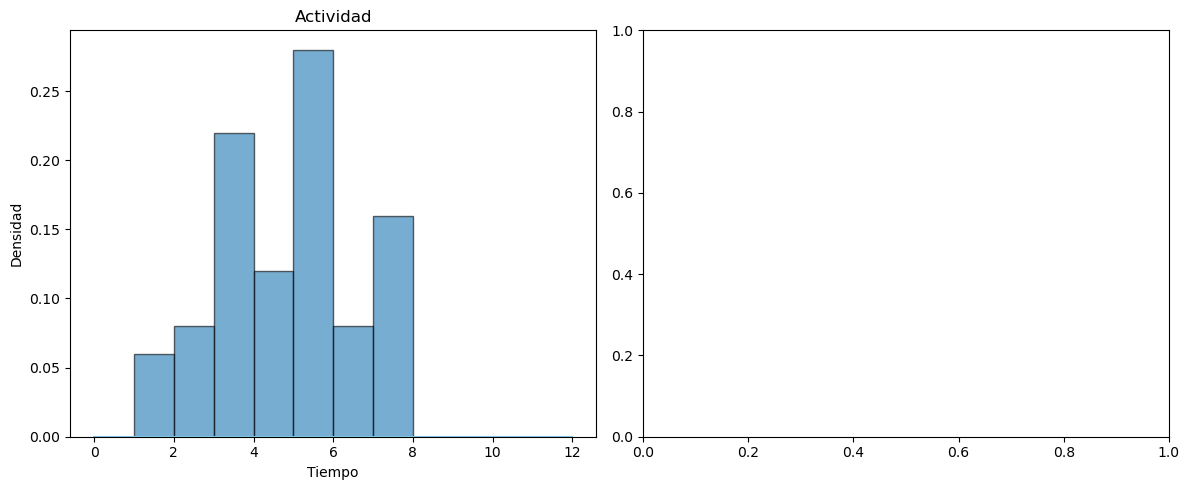

In [102]:
from scipy.stats import nbinom, poisson
import math as mt

# Rango de valores de n_E (hasta un máximo donde la probabilidad sea casi cero)
n_max = 12  # suficientemente grande
n_values = np.arange(0, n_max + 1)

# Calculamos la probabilidad para cada n
prob = np.zeros_like(n_values, dtype=float)

# Contribución de la parte continua (Poisson) para todo n
poisson =  (np.exp(-alpha_hat*60) * np.power(alpha_hat*60, n_values) / 
                  [mt.factorial(int(n)) for n in n_values])

############################################################
# HISTOGRAMA + AJUSTE
############################################################

fig, ax = plt.subplots(1,2, figsize=(12,5))

##############################################

x = np.linspace(0,max(n),8)

r = alpha_hat/sigma_hat

q = sigma_hat*Delta_t/(1.0 + sigma_hat*Delta_t)

ax[0].hist(
    n,
    bins='auto',
    density=True,
    alpha=0.6,
    edgecolor='k'
)

ax[0].plot(n_values, prob, color='skyblue')

ax[0].set_title("Actividad")
ax[0].set_xlabel("Tiempo")
ax[0].set_ylabel("Densidad")
#ax[0].legend()


plt.tight_layout()
plt.show()